# Libraries

In [2]:
%load_ext autoreload
%autoreload 2
# Libraries
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import shap
import captum
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Bundle net repo
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
# xai methods .py documents
from xai_methods import BehaviorWrapper, get_integrated_gradients, get_shap_values, generate_and_save_full_matrices
from xai_visualizations import plot_global_importance, plot_shap_beeswarm, generate_comparison_table, create_wide_interactive_panel, create_interactive_temporal_dashboard
from xai_tests import evaluate_rar, sperman_correlation_xai, generate_inter_worm_correlation


## Dowloading matrixes for XAi 

In [3]:
ig_matrix_0 = np.load("xai_matrices\worm_0_ig.npy")
shap_matrix_0 = np.load("xai_matrices\worm_0_shap.npy")

ig_matrix_1 = np.load("xai_matrices\worm_1_ig.npy")
shap_matrix_1 = np.load("xai_matrices\worm_1_shap.npy")

ig_matrix_2 = np.load("xai_matrices\worm_2_ig.npy")
shap_matrix_2 = np.load("xai_matrices\worm_2_shap.npy")

ig_matrix_3 = np.load("xai_matrices\worm_3_ig.npy")
shap_matrix_3 = np.load("xai_matrices\worm_3_shap.npy")

ig_matrix_4 = np.load("xai_matrices\worm_4_ig.npy")
shap_matrix_4 = np.load("xai_matrices\worm_4_shap.npy")

# Dowloading data

In [4]:
x_0 = np.load("precomputed_data\data\worm_0_x.npy")
b_0 = np.load("precomputed_data\data\worm_0_b.npy")
with open("precomputed_data\data\worm_0_neuron_names.json", "r") as f:
    neuron_names_0 = json.load(f)

x_1 = np.load("precomputed_data\data\worm_1_x.npy")
b_1 = np.load("precomputed_data\data\worm_1_b.npy")
with open("precomputed_data\data\worm_1_neuron_names.json", "r") as f:
    neuron_names_1 = json.load(f)

x_2 = np.load("precomputed_data\data\worm_2_x.npy")
b_2 = np.load("precomputed_data\data\worm_2_b.npy")
with open("precomputed_data\data\worm_2_neuron_names.json", "r") as f:
    neuron_names_2 = json.load(f)

x_3 = np.load("precomputed_data\data\worm_3_x.npy")
b_3 = np.load("precomputed_data\data\worm_3_b.npy")
with open("precomputed_data\data\worm_3_neuron_names.json", "r") as f:
    neuron_names_3 = json.load(f)

x_4 = np.load("precomputed_data\data\worm_4_x.npy")
b_4 = np.load("precomputed_data\data\worm_4_b.npy")
with open("precomputed_data\data\worm_4_neuron_names.json", "r") as f:
    neuron_names_4 = json.load(f)

# Dowloading models

In [6]:
with open("precomputed_data/behavior_names.json", "r") as f:
    raw_behaviors = json.load(f)
    behavior_names = {int(k): v for k, v in raw_behaviors.items()}
    num_behaviors = len(behavior_names)

#### WORM 0
model_0 = BunDLeNet(
    latent_dim=3, 
    num_behaviour=num_behaviors, 
    input_shape=x_0.shape
)

model_0.load_state_dict(torch.load("precomputed_data\models\worm_0_model.pt"))
model_0.eval()

#### WORM 1
model_1 = BunDLeNet(
    latent_dim=3, 
    num_behaviour=num_behaviors, 
    input_shape=x_1.shape
)

model_1.load_state_dict(torch.load("precomputed_data\models\worm_1_model.pt"))
model_1.eval()

#### WORM 2
model_2 = BunDLeNet(
    latent_dim=3, 
    num_behaviour=num_behaviors, 
    input_shape=x_2.shape
)

model_2.load_state_dict(torch.load("precomputed_data\models\worm_2_model.pt"))
model_2.eval()

#### WORM 3
model_3 = BunDLeNet(
    latent_dim=3, 
    num_behaviour=num_behaviors, 
    input_shape=x_3.shape
)

model_3.load_state_dict(torch.load("precomputed_data\models\worm_3_model.pt"))
model_3.eval()

#### WORM 4
model_4 = BunDLeNet(
    latent_dim=3, 
    num_behaviour=num_behaviors, 
    input_shape=x_4.shape
)

model_4.load_state_dict(torch.load("precomputed_data\models\worm_4_model.pt"))
model_4.eval()

BunDLeNet(
  (tau): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=129, out_features=50, bias=True)
    (2): ReLU()
    (3): Linear(in_features=50, out_features=30, bias=True)
    (4): ReLU()
    (5): Linear(in_features=30, out_features=25, bias=True)
    (6): ReLU()
    (7): Linear(in_features=25, out_features=10, bias=True)
    (8): ReLU()
    (9): Linear(in_features=10, out_features=3, bias=True)
    (10): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): GaussianNoise()
  )
  (T_Y): Sequential(
    (0): Linear(in_features=3, out_features=3, bias=True)
  )
  (predictor): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
  )
)

# **GLOBAL IMPORTANCE PANEL**

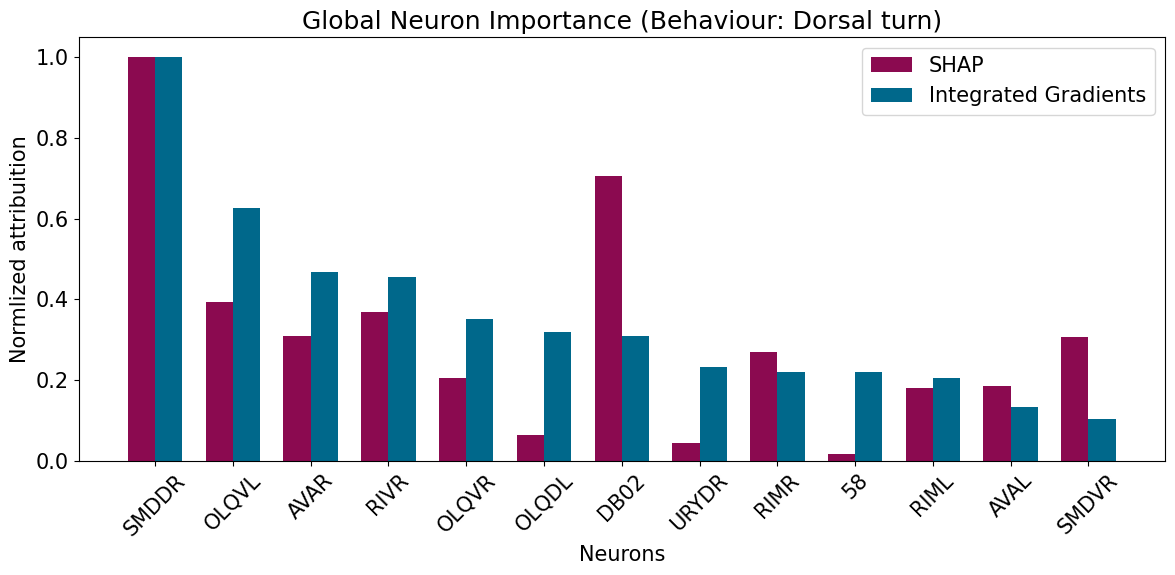

In [95]:
plt.rcParams.update({'font.size': 15})
plot_global_importance(attributions_shap = shap_matrix_0, attributions_ig = ig_matrix_0, b_labels = b_0, target_behavior = 0, top_n=10, neuron_names= neuron_names_0, behavior_names= behavior_names, title="Global Neuron Importance")


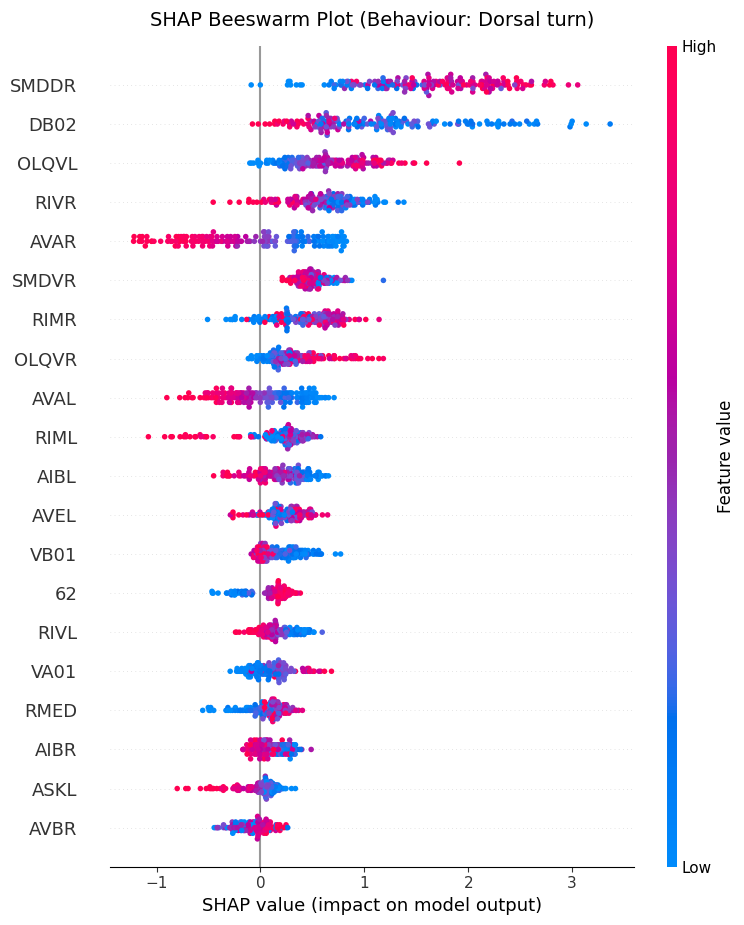

In [96]:
plot_shap_beeswarm(shap_attr = shap_matrix_0, x_windowed= x_0, b_labels = b_0,  target_behavior= 0, behavior_names= behavior_names, neuron_names= neuron_names_0) 

In [97]:
df_comparison = generate_comparison_table(attributions_shap= shap_matrix_0, attributions_ig=ig_matrix_0, b_labels= b_0, target_behavior= 0, neuron_names= neuron_names_0)
display(df_comparison)

,Top IG,Top SHAP (Absolutne),SHAP Positive (Netto +),SHAP Negative (Netto -)
Place,,,,
1,SMDDR,SMDDR,SMDDR,AVAR
2,OLQVL,DB02,DB02,AVBR
3,AVAR,OLQVL,OLQVL,87
4,RIVR,RIVR,RIVR,ASKR
5,OLQVR,AVAR,SMDVR,97
6,OLQDL,SMDVR,RIMR,VB02
7,DB02,RIMR,OLQVR,21
8,URYDR,OLQVR,AVEL,63
9,RIMR,AVAL,AIBL,ALA


In [98]:

# 3. Test IG z opcją Retrain
acc_ig, retained = evaluate_rar(
    x_windowed=x_0, 
    b_labels=b_0, 
    attributions=ig_matrix_0, 
    retain_percentage=0.10,
    epochs=200,          
    device=device
)
print(f"--> IG Results (Retrain): New model is left with: {retained} neurons.  New accuracy: {acc_ig * 100:.2f}%")

# 4. Test SHAP z opcją Retrain
acc_shap, _ = evaluate_rar(
    x_windowed=x_0, 
    b_labels=b_0, 
    attributions=shap_matrix_0, 
    retain_percentage=0.10,
    epochs=200,
    device=device
)
print(f"--> SHAP Results (Retrain): New model is left with: {retained} neurons. New accuracy: {acc_shap * 100:.2f}%")


 Traning (number of nurons: 10)...


Loss [Markov, Behaviour, Total]: [0.0126 0.0312 0.0438]: 100%|██████████| 200/200 [00:29<00:00,  6.81it/s]


--> IG Results (Retrain): New model is left with: 10 neurons.  New accuracy: 89.13%

 Traning (number of nurons: 10)...


Loss [Markov, Behaviour, Total]: [0.0128 0.0309 0.0437]: 100%|██████████| 200/200 [00:28<00:00,  6.92it/s]

--> SHAP Results (Retrain): New model is left with: 10 neurons. New accuracy: 88.78%


In [71]:
corr, p_val = sperman_correlation_xai(shap_matrix_0, ig_matrix_0)

print(f"Correlatio Spearman's rangs: {corr:.3f}")
if p_val < 0.05:
    print(f" p-value: {p_val:.3e} (Results is statisticlly significant)")
else:
    print(f" p-value: {p_val:.3e} (Results is not statisticlly significant)")

Correlatio Spearman's rangs: 0.837
 p-value: 8.370e-30 (Results is statisticlly significant)


# **WORM SPECIFIC PANEL**

In [7]:
my_custom_palette = [
    '#FF82AB',  
    '#8B4789',  
    '#87CEFA',  
    '#7CCD7C',  
    '#B3EE3A',  
    '#FF6A6A',  
    '#009ACD',  
    '#FFB90F'   
]

In [8]:
panel = create_wide_interactive_panel(x_ = x_0,
                                    model = model_0,
                                    behaviors= b_0,
                                    shap_matrix= shap_matrix_0,
                                    ig_matrix= ig_matrix_0, neuron_names=neuron_names_1, behavior_names=behavior_names, palette= my_custom_palette)

In [9]:
display(panel)

    'data': [{'hoverinfo': 'text',
              'line': {'cmax': 7,
           …

In [ ]:
df_corr_shap = generate_inter_worm_correlation(
    target_behavior=0, 
    ref_worm_idx=0, 
    total_worms=5,          
    method='shap',           
    behavior_names=behavior_names 
)

display(df_corr_shap)

,Comparrasion,Common neurons,Correlation,P-value
IG | Sustained reversal | Base: Worm 0,,,,
0,Worm 1,83,0.481,< 0.05
1,Worm 2,77,0.362,< 0.05
2,Worm 3,77,0.396,< 0.05
3,Worm 4,83,0.355,< 0.05


In [94]:
df_corr_shap = generate_inter_worm_correlation(
    target_behavior=0, 
    ref_worm_idx=0, 
    total_worms=5,          
    method='ig',           
    behavior_names=behavior_names 
)

display(df_corr_shap)

,Comparrasion,Common neurons,Correlation,P-value
IG | Dorsal turn | Base: Worm 0,,,,
0,Worm 1,83,0.186,0.093
1,Worm 2,77,0.061,0.596
2,Worm 3,77,0.325,< 0.05
3,Worm 4,83,0.230,< 0.05


# **HEATMAP PANEL**

In [10]:

# Generowanie interaktywnego panelu (z domyślnym zoomem na top 10)
dashboard = create_interactive_temporal_dashboard(
    x_raw=x_0, 
    behaviors=b_0, 
    behavior_names=behavior_names, 
    shap_matrix=shap_matrix_0,    
    ig_matrix= ig_matrix_0,
    neuron_names=neuron_names_0,
    palette=my_custom_palette,
    top_n=10                    
)

display(dashboard)

FigureWidget({
    'data': [{'colorbar': {'len': 0.3, 'title': {'text': 'Activation'}, 'x': 1.01, 'y': 0.84, 'yanchor': 'middle'},
              'colorscale': [[0.0, '#000004'], [0.1111111111111111, '#180f3d'],
                             [0.2222222222222222, '#440f76'], [0.3333333333333333,
                             '#721f81'], [0.4444444444444444, '#9e2f7f'],
                             [0.5555555555555556, '#cd4071'], [0.6666666666666666,
                             '#f1605d'], [0.7777777777777778, '#fd9668'],
                             [0.8888888888888888, '#feca8d'], [1.0, '#fcfdbf']],
              'type': 'heatmap',
              'uid': 'e895e74f-e04c-406c-994b-9d8fffffac30',
              'xaxis': 'x',
              'y': array(['86', '77', '31', '27', '49', '89', '18', '47', '33', '5', '25', '6',
                          '8', '76', '88', '12', '22', '59', '90', '84', '52', '21', '20', '4',
                          '48', '7', 'VB02', '83', '80', '74', '2', '34', '85', 